<h2>Regresión Lineal</h2>



Referencia: <a href='https://www.cienciadedatos.net/documentos/24_correlacion_y_regresion_lineal'>Ciencia de datos</a>
<br>
Para cada uno de los parámetros de la ecuación de regresión lineal simple (β0 y β1) se puede calcular 
su significancia (p-value) y su intervalo de confianza. 

- H0: No hay relación lineal entre ambas variables, por lo que la pendiente del modelo lineal es 0.
- H1: Si hay relación lineal, por tanto la pendiente del modelo lineal es diferente de 0

In [4]:
load('.RData')

In [8]:
library(ggplot2)
library(tidyverse)
library(ggpubr)

In [5]:
#Se van a utilizar el dataset sin NA
head(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


<h4>1. Adelie</h4>

In [15]:
lm_adelie <- lm(flipper_length_mm ~ body_mass_g, data = df[df$species == 'Adelie', ])
summary(lm_adelie)


Call:
lm(formula = flipper_length_mm ~ body_mass_g, data = df[df$species == 
    "Adelie", ])

Residuals:
    Min      1Q  Median      3Q     Max 
-14.426  -3.669   0.239   3.422  17.955 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.656e+02  3.918e+00   42.27  < 2e-16 ***
body_mass_g 6.610e-03  1.049e-03    6.30  3.4e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.794 on 144 degrees of freedom
Multiple R-squared:  0.2161,	Adjusted R-squared:  0.2106 
F-statistic: 39.69 on 1 and 144 DF,  p-value: 3.402e-09


In [16]:
confint(lm_adelie)

,2.5 %,97.5 %
(Intercept),1.578589e+02,1.733476e+02
body_mass_g,4.536603e-03,8.684342e-03


`geom_smooth()` using formula 'y ~ x'



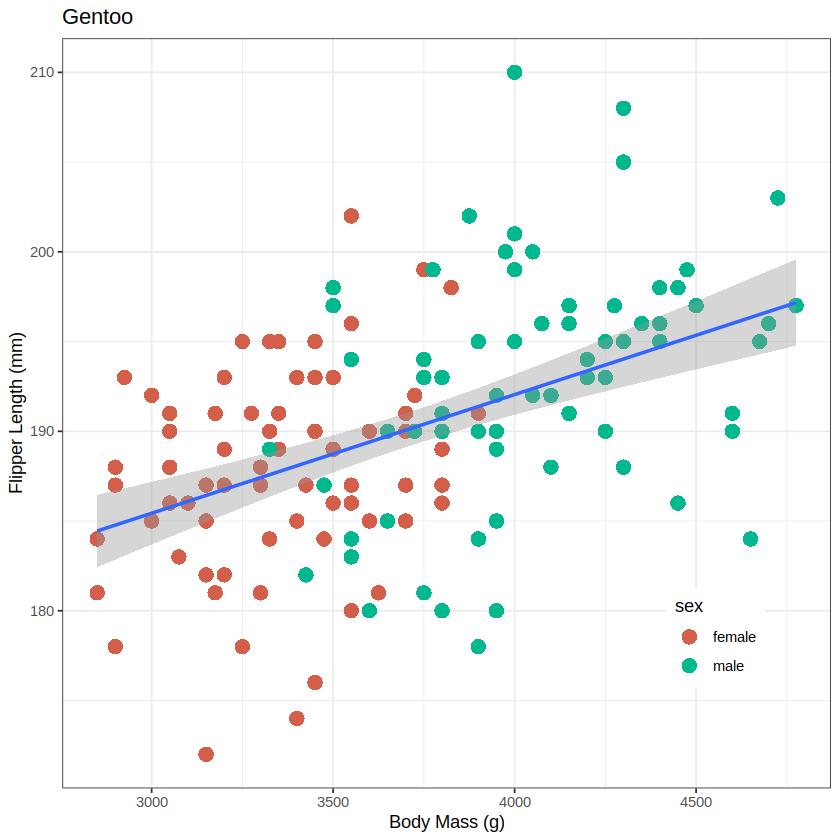

In [17]:
ggplot(data = df[df$species == 'Adelie', ], 
        aes(y = flipper_length_mm, x = body_mass_g)) +
        geom_point(size = 4, pch=16, aes(color = sex , shape = sex)) + 
        scale_color_manual(values = sex_color)+
        geom_smooth(method = 'lm', se = TRUE) +
        labs(  y = "Flipper Length (mm)",
               x = "Body Mass (g)") +
        ggtitle("Gentoo ") +
        theme_bw() +
        theme(legend.position = c(0.85, 0.2))

<h4>Verificar condiciones para poder aceptar un modelo lineal</h4>

In [21]:
datos <- df[df$species == 'Adelie', ]
datos$prediccion <- lm_adelie$fitted.values
datos$residuos <- lm_adelie$residuals
head(datos)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,prediccion,residuos
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>,<dbl>,<dbl>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007,190.3925,-9.3925139
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007,190.7230,-4.7230375
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007,187.0873,7.9127225
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007,188.4094,4.5906280
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007,189.7315,0.2685334
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007,189.5662,-8.5662048


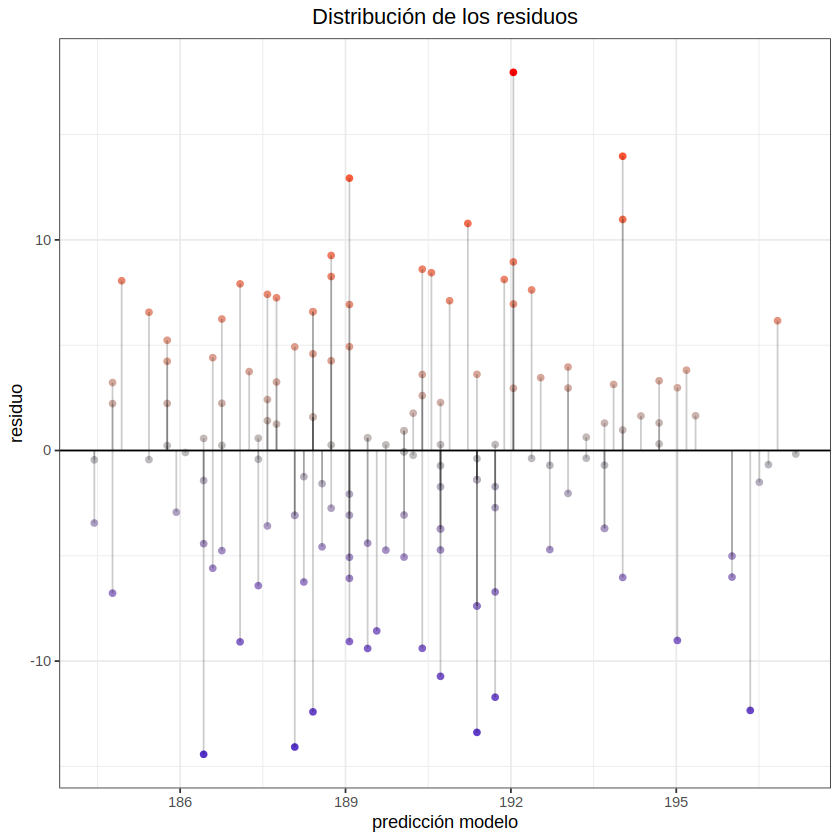

In [24]:
ggplot(data = datos, aes(x = prediccion, y = residuos)) +
  geom_point(aes(color = residuos)) +
  scale_color_gradient2(low = "blue3", mid = "grey", high = "red") +
  geom_hline(yintercept = 0) +
  geom_segment(aes(xend = prediccion, yend = 0), alpha = 0.2) +
  labs(title = "Distribución de los residuos", x = "predicción modelo",
       y = "residuo") +
  theme_bw() +
  theme(plot.title = element_text(hjust = 0.5), legend.position = "none")

## Los residuos se distribuyen de forma aleatoria entorno al 0 por lo que se acepta la linealidad.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



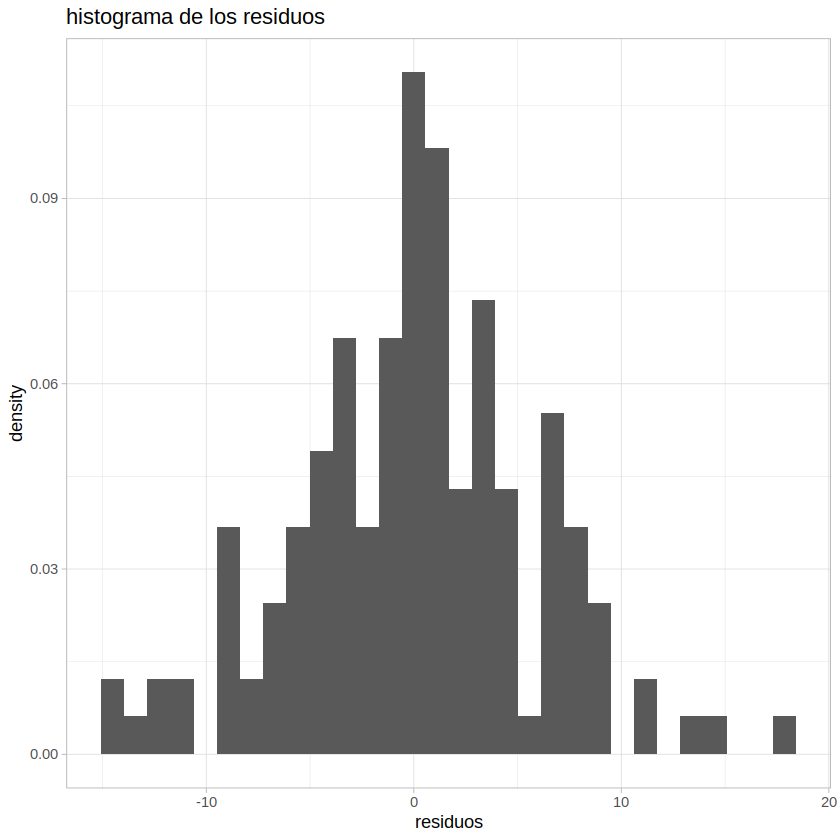

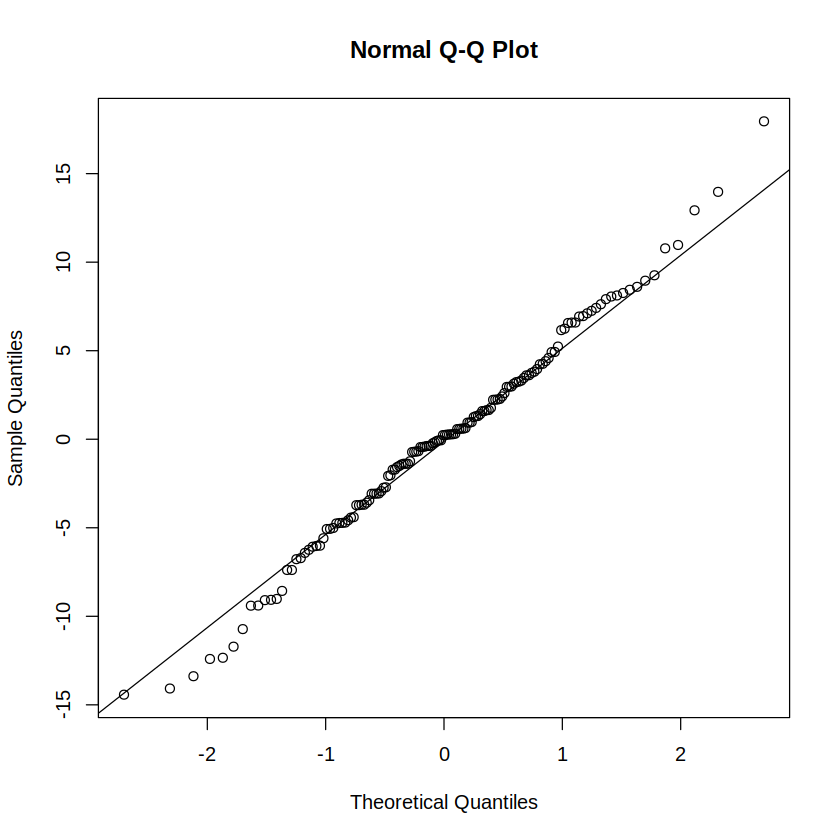

In [27]:
## os residuos se deben distribuir de forma normal con media 0. 
## Para comprobarlo se recurre a histogramas, a los cuantiles normales 
## o a un test de contraste de normalidad.

ggplot(data = datos, aes(x = residuos)) +
  geom_histogram(aes(y = ..density..)) +
  labs(title = "histograma de los residuos") +
  theme_light()

qqnorm(lm_adelie$residuals)
qqline(lm_adelie$residuals)

`geom_smooth()` using method = 'loess' and formula 'y ~ x'



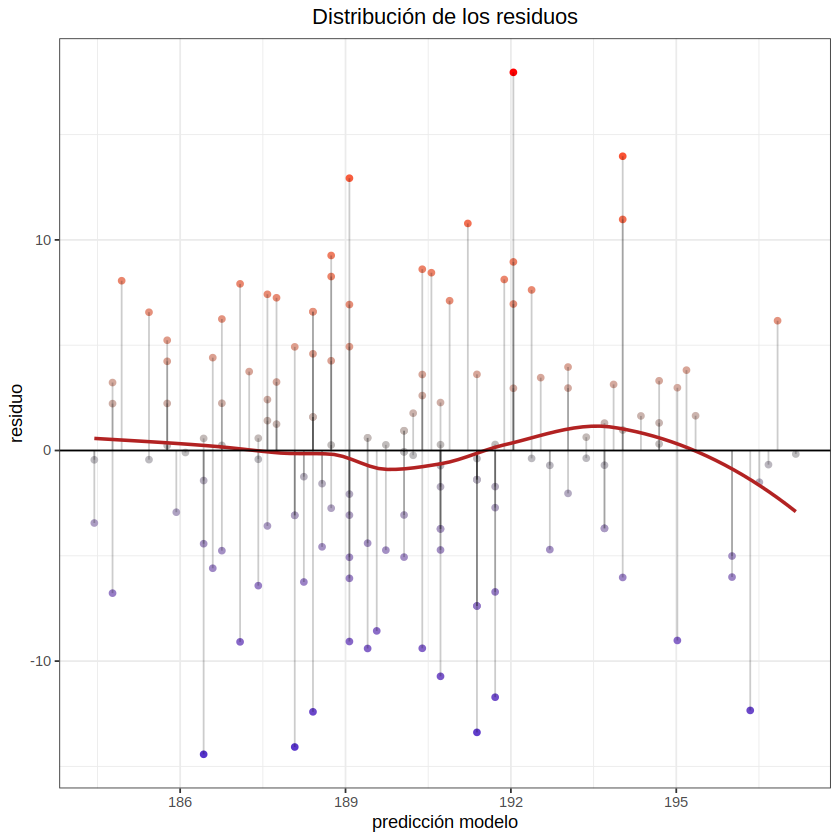

In [28]:
## Varianza constante de los residuos (Homocedasticidad):

ggplot(data = datos, aes(x = prediccion, y = residuos)) +
  geom_point(aes(color = residuos)) +
  scale_color_gradient2(low = "blue3", mid = "grey", high = "red") +
  geom_segment(aes(xend = prediccion, yend = 0), alpha = 0.2) +
  geom_smooth(se = FALSE, color = "firebrick") +
  labs(title = "Distribución de los residuos", x = "predicción modelo",
       y = "residuo") +
  geom_hline(yintercept = 0) +
  theme_bw() +
  theme(plot.title = element_text(hjust = 0.5), legend.position = "none")
